## Simulação

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from utils.simulacoes import simular_PID, simular_step_test

# from utils.plots import plot_results

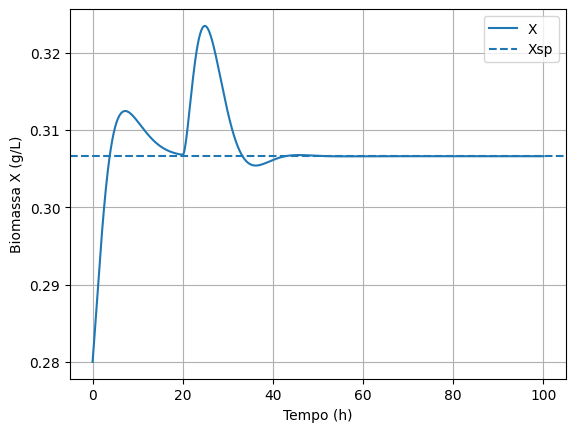

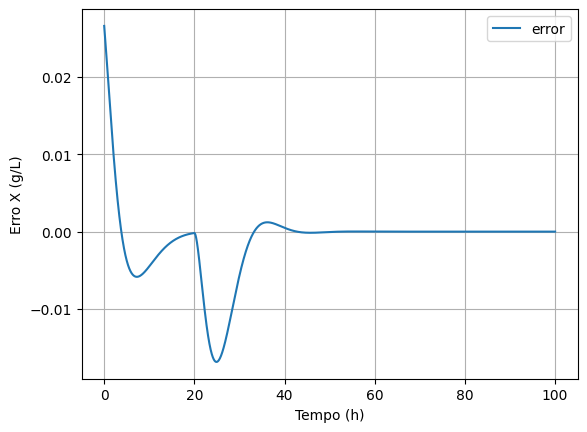

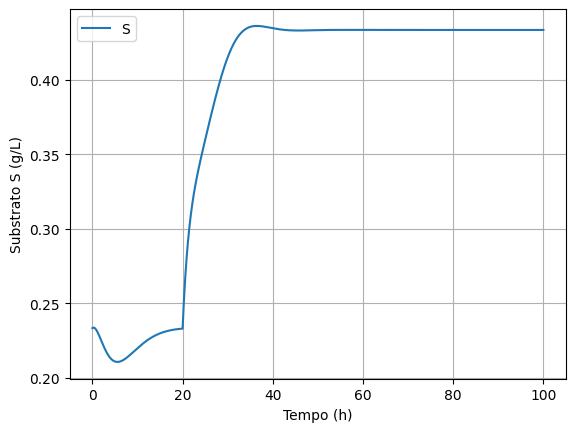

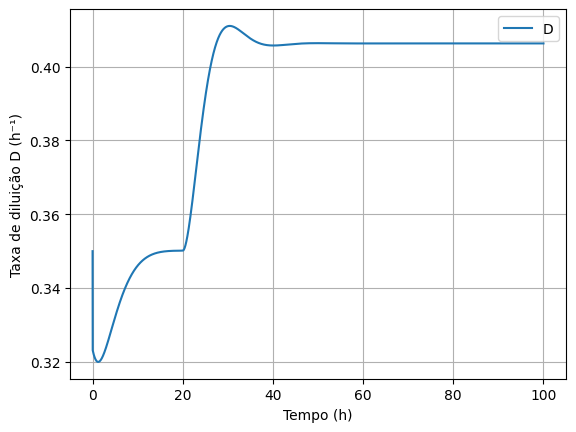

In [12]:
_ = simular_PID(Kc=-1.0, Ti=2, states= np.array([0.28, 0.2333]), pert=True, Sf_pert=1.2, t_pert=20)

## configurações

In [13]:

tf = 100.0
dt = 0.1

X0 = 0.3066
S0 = 0.2333

states = np.array([0.3066, 0.2333])

Xsp = 0.3066

D0 = 0.35


## Controlador usando IMC

Temos 
* saída controlada: (X)
* variável manipulada: (D)
* perturbação futura: (S_f)

Em que, 
$$
G_{X,D}(s)=
\frac{-0.30667s-0.10733}{s^2+0.695s+0.12075}
$$
ou, fatorando:

$$
G_{X,D}(s)=
\frac{-0.30667(s+0.35)}{(s+0.345)(s+0.35)}
$$
Após o cancelamento aproximado:

$$
G_{X,D}(s)\approx
\frac{-0.30667}{s+0.345}
$$

Então, **não aparece termo de atraso** do tipo:

$$
e^{-\theta s}
$$

Assim, escolhendo $$(\frac{Y}{Y_{sp}})_d = \frac{1}{\tau_c s + 1}$$

Para a fórmula geral do Direct Synthesis:

$$
G_c=\frac{1}{\tilde G}
\frac{(Y/Y_{sp})_d}{1-(Y/Y_{sp})_d}
$$

Então,

$$
G_c=\frac1{\tilde G}
\frac1{\tau_c s}
$$


Escrevendo na forma padrão:

$$
G_{X,D}(s)=\frac{K}{\tau s+1}
$$

tenho

$$
K=\frac{-0.30667}{0.345}=-0.889
$$

e

$$
\tau=\frac1{0.345}=2.90 \ h
$$

Então:

$$
\tilde G(s)=\frac{-0.889}{2.90s+1}
$$

substituindo no que obteve-se de Direct Synthesis:

$$
G_c(s)=\frac1{\tilde G(s)}
\frac1{\tau_c s}
$$

$$
= \frac{2.90s+1}{-0.889}
\frac1{\tau_c s}
$$

$$
= -\frac1{0.889\tau_c}
\frac{2.90s+1}{s}
$$

que é semelhante a [forma PI](https://electronicscoach.com/proportional-integral-controller.html):

$$
G_{PI}(s)=K_c\frac{\tau_I s+1}{\tau_I s}
$$


Daí sai direto:

$$
\tau_I = 2.90 \ h
$$

e

$$
K_c=-\frac{2.90}{0.889\tau_c}
$$




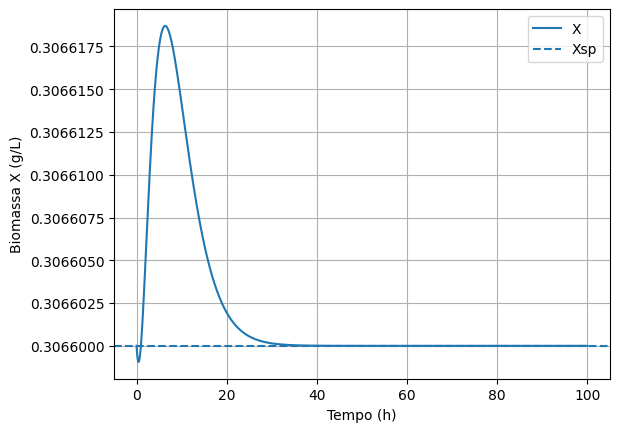

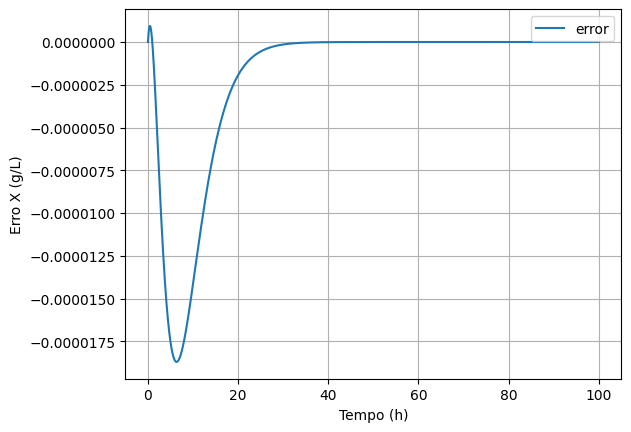

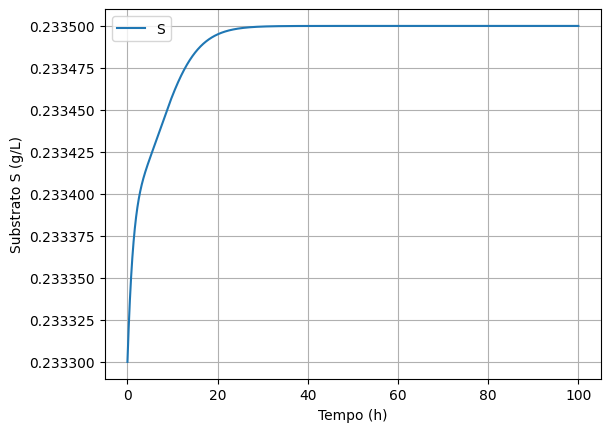

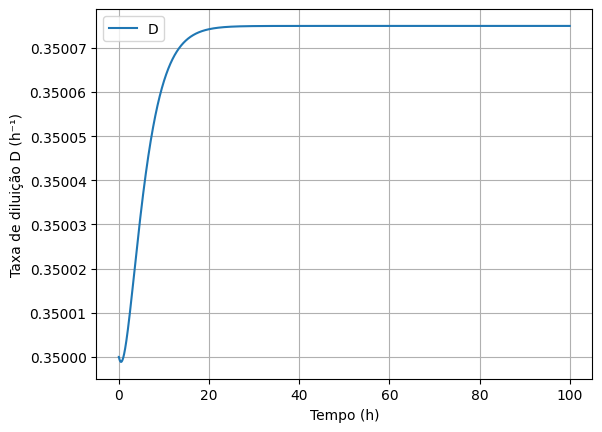

0.9600000000000001


In [14]:
# simulacao com Tc = 3h
Tc = 3  # h 
Kc = -2.9/(0.889*Tc)
Ti = 2.9 # h 
t1, X1, S1, D1, IAE_imc, ISE_imc, erro = simular_PID(Kc=Kc, Ti=Ti, Xsp=Xsp, D0=D0, states=states, tempo_final=tf)
c = 0
for i in erro:
    if i < 0:
        print(t1[c])
        break
    c+=1
# print(erro)

## Step Test Method

Inicialmente o processo já está em regime permanente

Em que
$$
D=0.35,\quad S_f=1.0
$$

e inicia em:

$$
X=0.3066,\quad S=0.2333
$$


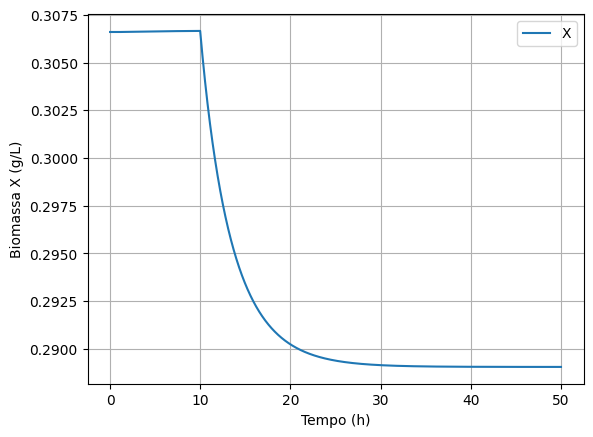

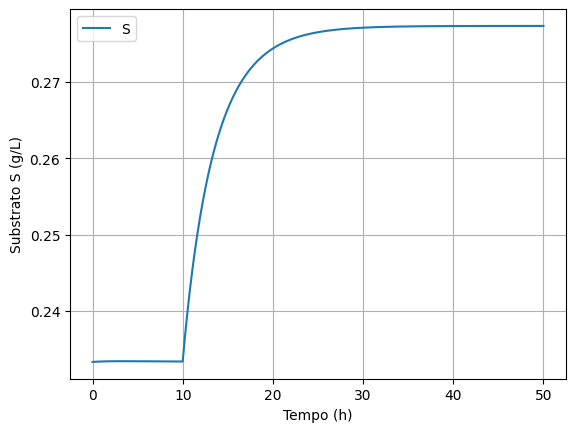

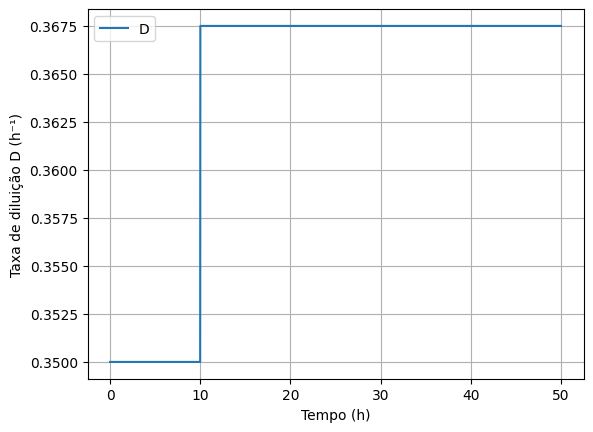

In [15]:
# entrada manipulada fixada em D0 - sem PID
# Aplicando  5% na saída do controlador em t = 10 h.
step_time = 10
t2, X2, S2, D2 = simular_step_test(D0=0.35, step_percent=0.05, step_time=step_time, states=np.array([0.3066, 0.2333]), tempo_final=50, dt=0.01)

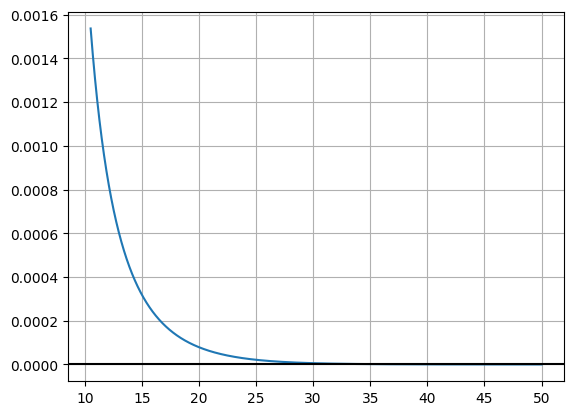

In [16]:
# verificando inflexão
dX = np.gradient(X2, t2)
d2X = np.gradient(dX, t2)
mask = t2 > 10.5

plt.figure()
plt.plot(t2[mask], d2X[mask])
plt.axhline(0, color='k')
plt.grid()
plt.show()

Após descontinuidade (t = 10), a segunda derivada não muda de sinal, não tendo ponto de inflexão -> não dá para usar tg aqui, mas tem o método de 63%.


usando método dos 63,2% e encontrar o instante em que a curva cruza esse valor:
$$
X_\tau=X_0 + 0.632(X_f-X_0)
$$

$$t_{63,2\%} = \text{instante de tempo de }X_\tau - \text{instante de tempo que ocorre degrau}$$

Como o processo é primeira ordem sem atraso

$$
G(s)=\frac{K}{\tau s + 1}
$$

onde:

$$
K = \frac{\Delta X}{\Delta D}
$$

e

$$
\tau = t_{63,2\%}
$$

Em seguida, escolho $\tau_c$ para usar a regra de sintonia do IMC para PI:

$$
K_c K = \frac{\tau}{\tau_c}
$$

$$
T_i = \tau
$$

Como o ganho do processo é K, então:

$$
K_c = \frac{\tau}{K\tau_c}
$$

e

$$
T_i = \tau
$$


Xtau = 0.296
tau = 3.520


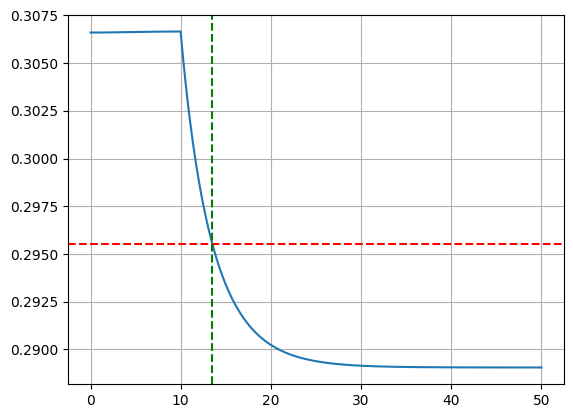

In [17]:

X0 = X2[0]
Xf = X2[-1]

Xtau = X0 + 0.632*(Xf - X0)
print(f"Xtau = {Xtau:.3f}")
idx = np.argmin(np.abs(np.array(X2) - Xtau))

tau = t2[idx] - step_time
print(f"tau = {tau:.3f}")

plt.figure()
plt.plot(t2, X2)
plt.axhline(Xtau, color='r', linestyle='--')
plt.axvline(step_time + tau, color='g', linestyle='--')
plt.grid()
plt.show()

In [18]:
# valor da entrada antes e depois do degrau
D0 = D2[0]
Df = D2[-1]

delta_X = Xf - X0
delta_D = Df - D0

K = delta_X / delta_D

# print(f"D0 = {D0:.4f}")
# print(f"Df = {Df:.4f}")
print(f"delta_X = {delta_X:.6f}")
print(f"delta_D = {delta_D:.6f}")
print(f"K = {K:.3f}")
print(f"tau = {tau:.3f} h")

delta_X = -0.017543
delta_D = 0.017500
K = -1.002
tau = 3.520 h


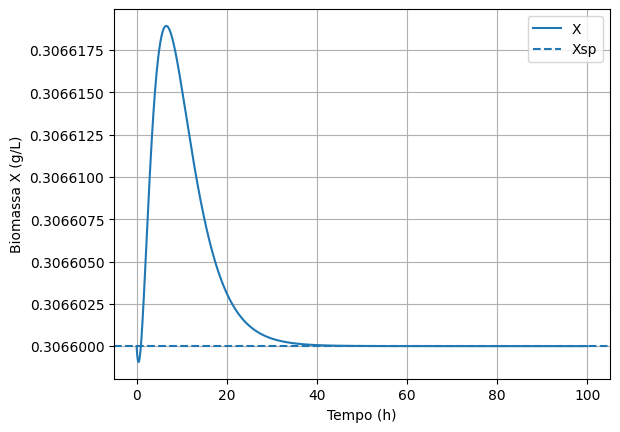

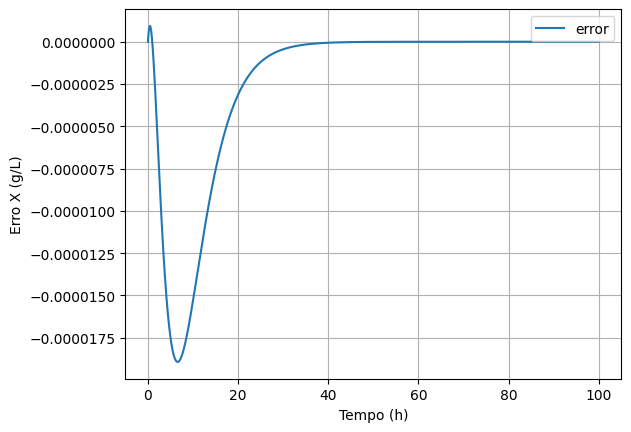

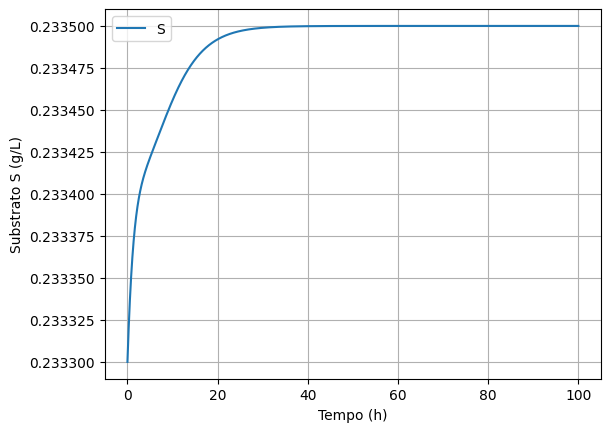

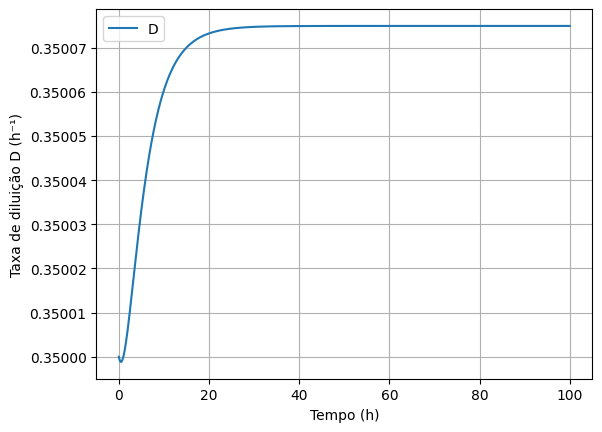

In [19]:
tau_c = 3
Kc_stepTest = tau / (K * tau_c)
Ti_stepTest = tau
Td_stepTest = 0

t_stepTest, X1_stepTest, S1_stepTest, D1_stepTest, IAE_stepTest, ISE_stepTest, erro_stepTest = simular_PID(Kc=Kc_stepTest, Ti=Ti_stepTest, Xsp=Xsp, D0=D0, states=states, tempo_final=tf)

## RELAY

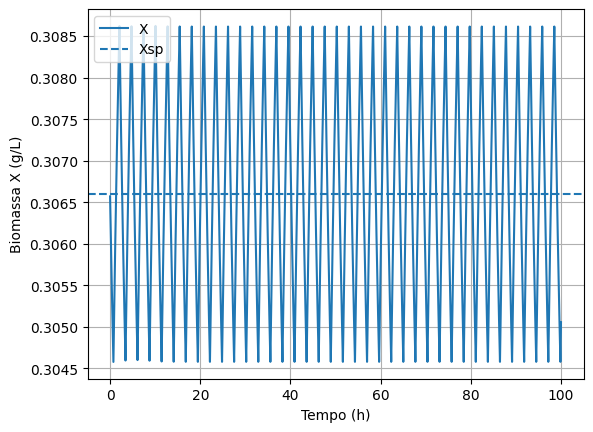

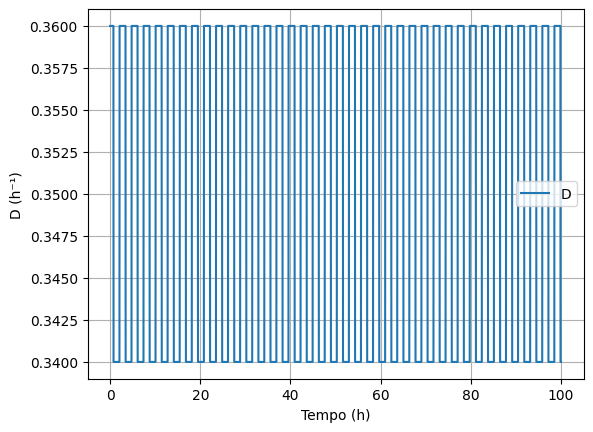

In [20]:
from utils.simulacoes import simular_relay_autotuning

t_relay, X_relay, S_relay, D_relay = simular_relay_autotuning(
    Xsp=0.3066,
    D0=0.35,
    d=0.01,
    dead_zone=0.002,
    states=np.array([0.3066, 0.2333]),
    tempo_final=100,
    dt=0.01
)

plt.figure()
plt.plot(t_relay, X_relay, label="X")
plt.axhline(0.3066, linestyle="--", label="Xsp")
plt.xlabel("Tempo (h)")
plt.ylabel("Biomassa X (g/L)")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(t_relay, D_relay, label="D")
plt.xlabel("Tempo (h)")
plt.ylabel("D (h⁻¹)")
plt.legend()
plt.grid()
plt.show()

a = 0.002018
Pu = 2.679 h
Kc = -2.840
Ti = 2.232 h
Td = 0.000 h


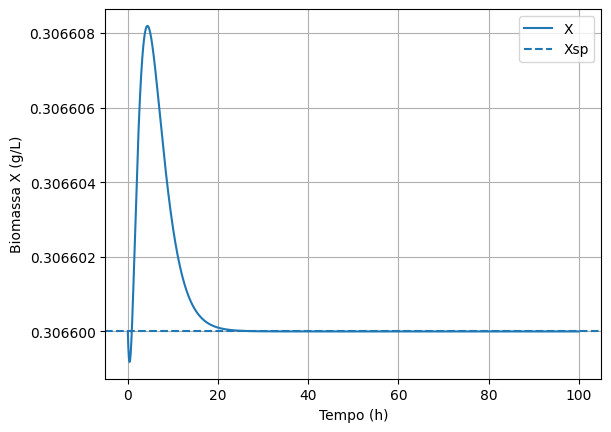

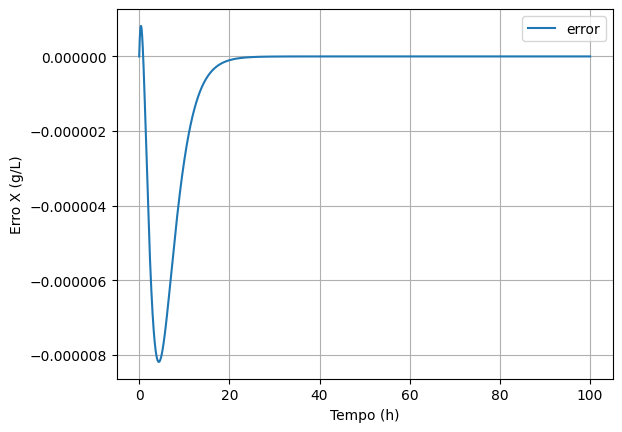

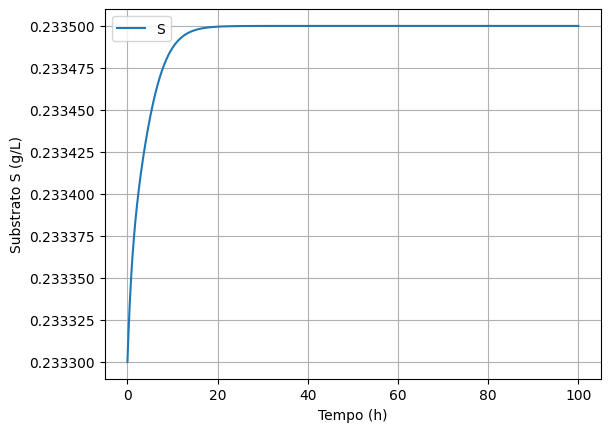

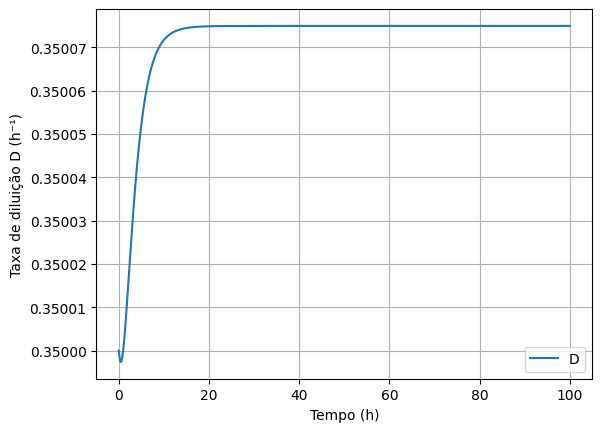

: 

In [ ]:
# parametros
from utils.simulacoes import estimar_parametros_relay
a, Pu, Kcu, Kc_relay, Ti_relay, Td_relay = estimar_parametros_relay(
    t_relay,
    X_relay,
    d=0.01,
    tempo_descartar=0
)

print(f"a = {a:.6f}")
print(f"Pu = {Pu:.3f} h")
# print(f"Kcu = {Kcu:.3f}")
print(f"Kc = {-Kc_relay:.3f}")
print(f"Ti = {Ti_relay:.3f} h")
print(f"Td = {Td_relay:.3f} h")

td, Xd, Sd, Dd, IAE_relay, ISE_relay,erro_relay = simular_PID(Kc=-Kc_relay, Ti=Ti_relay, Xsp=Xsp, D0=D0, states=states, tempo_final=tf)


## metricas

In [11]:
resultados = pd.DataFrame({
    "Controlador": ["Relay", "IMC", "Step Test"],
    "IAE": [IAE_relay, IAE_imc, IAE_stepTest],
    "ISE": [ISE_relay, ISE_imc, ISE_stepTest]
})

display(resultados)

,Controlador,IAE,ISE
0,Relay,0.000060,3.347167e-10
1,IMC,0.000201,2.600666e-09
2,Step Test,0.000227,2.916591e-09


## Com pertubação

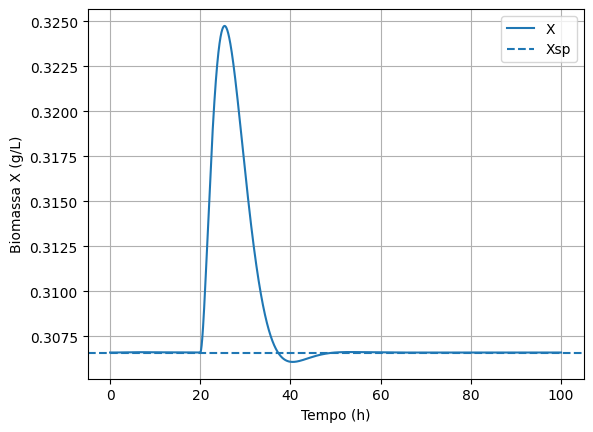

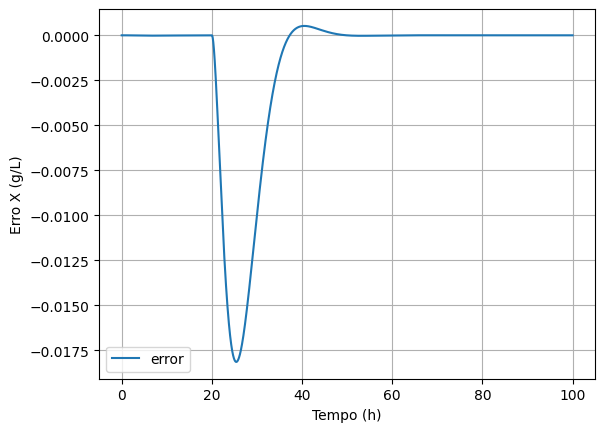

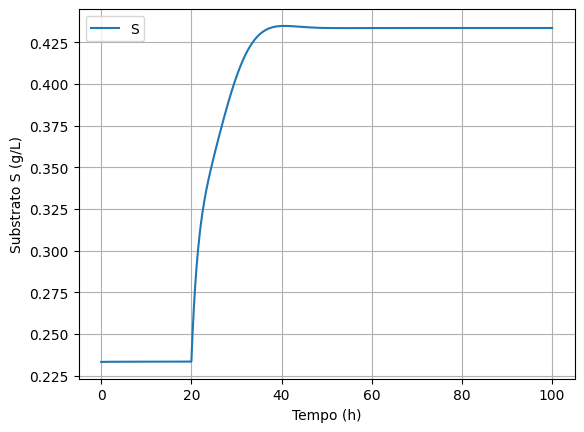

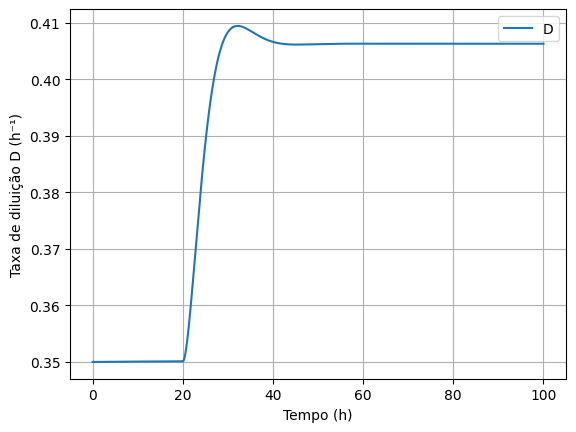

In [12]:
# simulacao com Tc = 3h
Tc = 3  # h 
Kc = -2.9/(0.889*Tc)
Ti = 2.9 # h 
t1, X1, S1, D1, IAE_imc_pertubado, ISE_imc_pertubado, erro_pertubado  = simular_PID(Kc=Kc, Ti=Ti, Xsp=Xsp, D0=D0, states=states, tempo_final=tf, pert=True, t_pert=20, Sf_pert = 1.2)


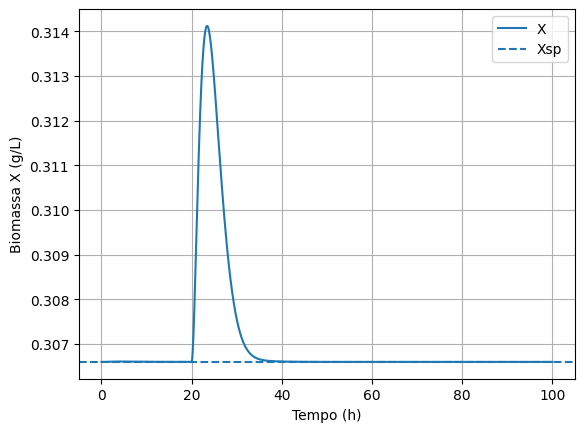

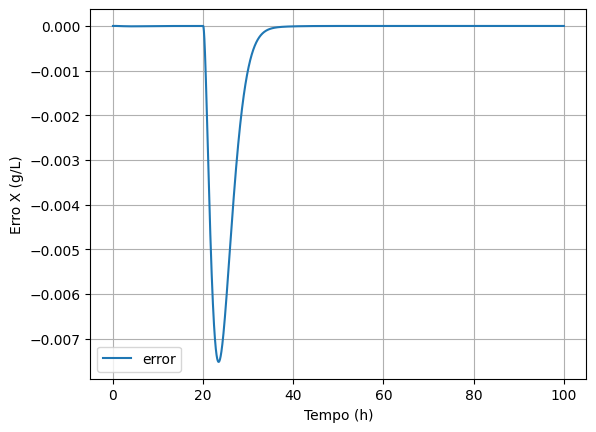

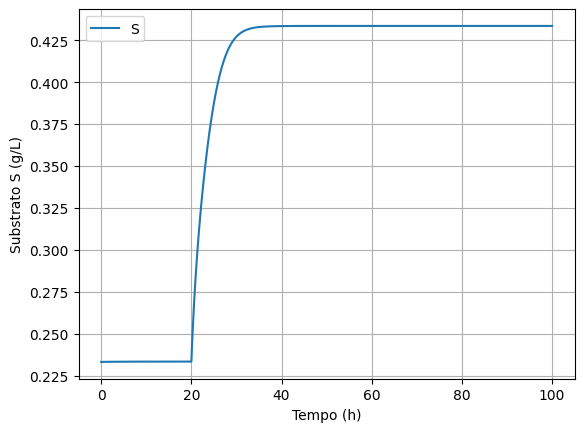

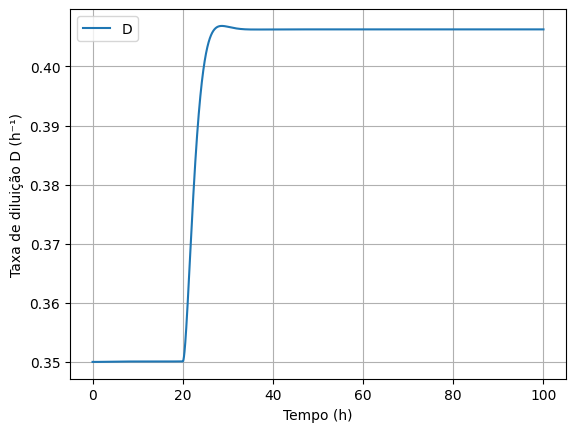

In [13]:
td, Xd, Sd, Dd, IAE_relay_pertubado, ISE_relay_pertubado, erro_relay_pertubado = simular_PID(Kc=-Kc_relay, Ti=Ti_relay, Xsp=Xsp, D0=D0, states=states, tempo_final=tf, pert=True, t_pert=20, Sf_pert=1.2)

In [14]:
resultados = pd.DataFrame({
    "Controlador": ["Relay", "IMC"],
    "IAE": [IAE_relay_pertubado, IAE_imc_pertubado],
    "ISE": [ISE_relay_pertubado, ISE_imc_pertubado]
})

display(resultados)

,Controlador,IAE,ISE
0,Relay,0.044245,0.000235
1,IMC,0.157028,0.002044


## Mudando Xsp

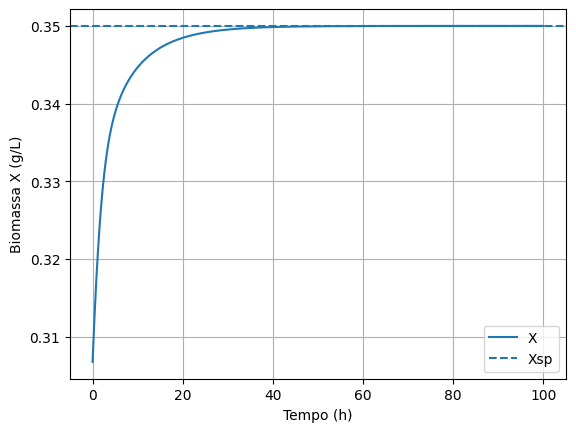

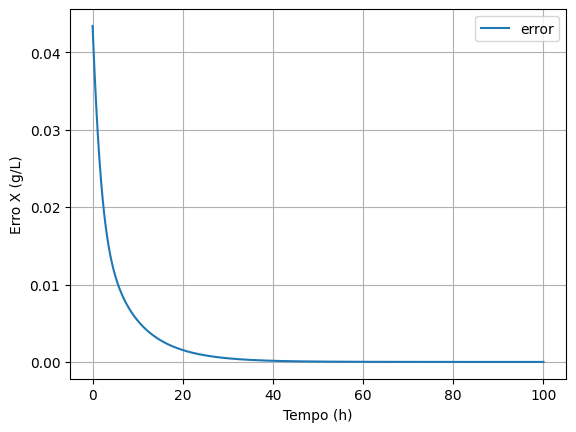

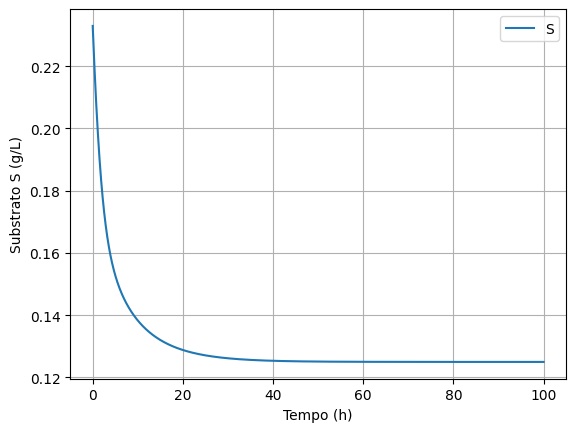

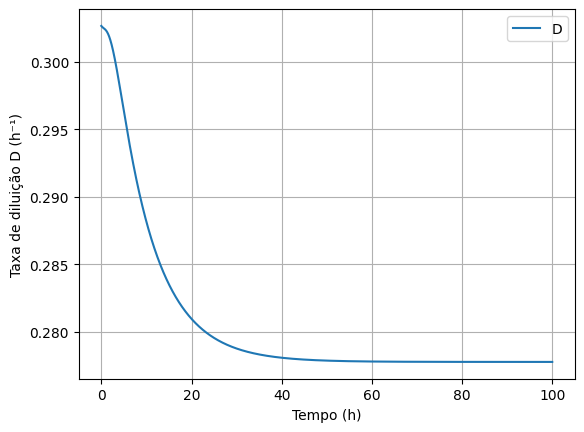

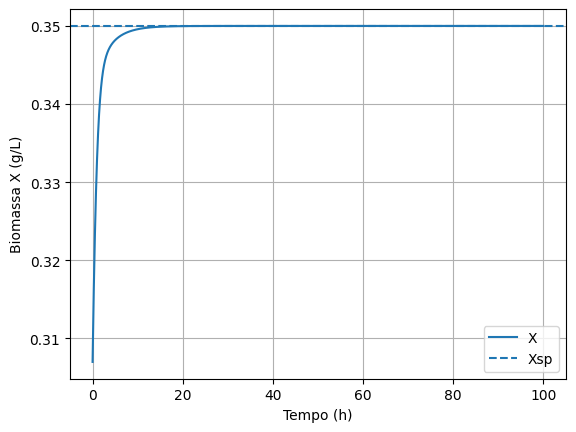

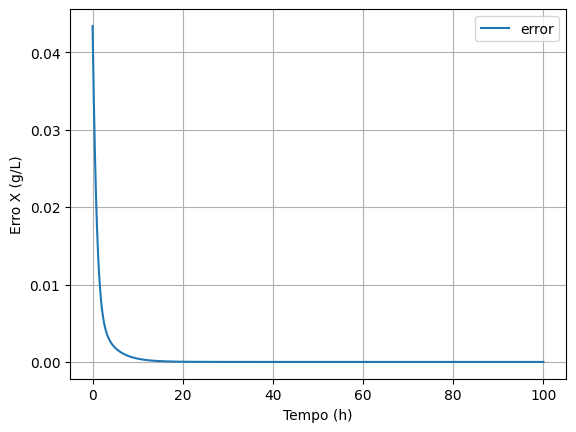

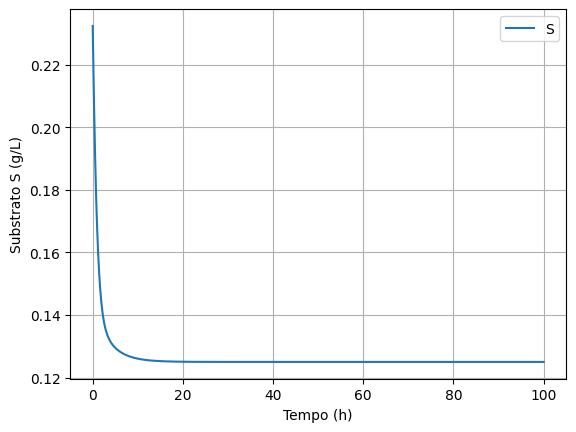

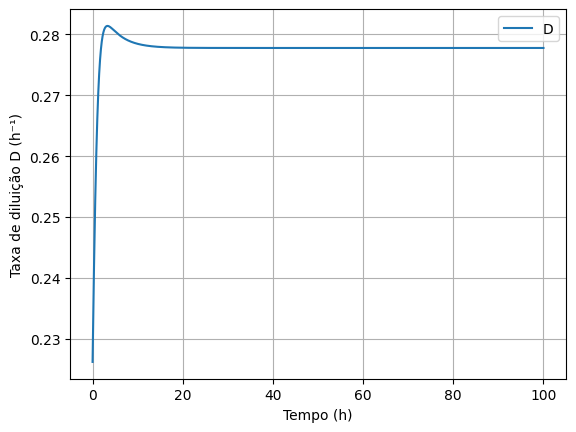

,Controlador,IAE,ISE
0,Relay,0.056128,0.001030
1,IMC,0.191965,0.003258


In [15]:
# simulacao com Tc = 3h
Tc = 3  # h 
Kc = -2.9/(0.889*Tc)
Ti = 2.9 # h 
Xsp = 0.35
t1, X1, S1, D1, IAE_imc_Xsp, ISE_imc_Xsp, erro_Xsp  = simular_PID(Kc=Kc, Ti=Ti, Xsp=Xsp, D0=D0, states=states, tempo_final=tf, pert=False, t_pert=20, Sf_pert = 1.2)

td, Xd, Sd, Dd, IAE_relay_Xsp, ISE_relay_Xsp, erro_relay_Xsp = simular_PID(Kc=-Kc_relay, Ti=Ti_relay, Xsp=Xsp, D0=D0, states=states, tempo_final=tf, pert=False, t_pert=20, Sf_pert=1.2)
resultados = pd.DataFrame({
    "Controlador": ["Relay", "IMC"],
    "IAE": [IAE_relay_Xsp, IAE_imc_Xsp],
    "ISE": [ISE_relay_Xsp, ISE_imc_Xsp]
})

display(resultados)

In [2]:
# =========================
# Parâmetros dos métodos
# =========================

# IMC / sincronização direta
tau_imc = 2.90
K_imc = -0.889
tau_c_imc = 3.0

Kc_imc = tau_imc / (K_imc * tau_c_imc)
Ti_imc = tau_imc

# Resultado:
# Kc_imc = -1.087
# Ti_imc = 2.90


# Step Test Method
tau_stepTest = 3.52
K_stepTest = -1.002
tau_c_stepTest = 3.0

Kc_stepTest = tau_stepTest / (K_stepTest * tau_c_stepTest)
Ti_stepTest = tau_stepTest

# Resultado:
# Kc_stepTest = -1.171
# Ti_stepTest = 3.52


# Relay
Kc_relay = -2.841
Ti_relay = 2.231

In [3]:
def rodar_pid(nome, Kc, Ti, **kwargs):
    tempo, X, S, D, IAE, ISE, erro = simular_PID(
        Kc=Kc,
        Ti=Ti,
        D0=0.35,
        show=False,
        **kwargs
    )

    return {
        "nome": nome,
        "tempo": np.array(tempo),
        "X": np.array(X),
        "S": np.array(S),
        "D": np.array(D),
        "erro": np.array(erro),
        "IAE": IAE,
        "ISE": ISE,
        "Kc": Kc,
        "Ti": Ti
    }


def plotar_comparacao_pid(
    resultados,
    titulo,
    Xsp=0.3066,
    t_pert=None,
    Sf_pert=None
):
    tempo = resultados[0]["tempo"]

    fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
    fig.suptitle(titulo, fontsize=14)

    for r in resultados:
        axes[0].plot(tempo, r["X"], label=r["nome"], linewidth=2)
        axes[1].plot(tempo, r["D"], label=r["nome"], linewidth=2)
        axes[2].plot(tempo, r["erro"], label=r["nome"], linewidth=2)

    axes[0].axhline(Xsp, linestyle="--", color="black", linewidth=1, label="Xsp")
    axes[2].axhline(0, linestyle="--", color="black", linewidth=1)

    axes[0].set_ylabel("X (g/L)")
    axes[1].set_ylabel("D (h⁻¹)")
    axes[2].set_ylabel("erro")
    axes[2].set_xlabel("Tempo (h)")

    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend()

    if t_pert is not None:
        for ax in axes:
            ax.axvline(t_pert, linestyle=":", color="gray", linewidth=1.5)

        axes[0].text(
            t_pert,
            axes[0].get_ylim()[1],
            f" Sf → {Sf_pert}",
            va="top",
            ha="left",
            fontsize=10
        )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# def comparar_metodos_sincronizacao():
#     Xsp_default = 0.3066
#     states_default = np.array([0.3066, 0.2333])
#     states_diferente = np.array([0.28, 0.2333])

#     tf = 100.0

#     # IMC
#     Tc = 3
#     Kc_imc = -2.9 / (0.889 * Tc)
#     Ti_imc = 2.9

#     # Step Test
#     Kc_step = Kc_stepTest
#     Ti_step = Ti_stepTest

#     # Relay
#     Kc_relay_final = -Kc_relay
#     Ti_relay_final = Ti_relay

#     metodos = [
#         ("IMC", Kc_imc, Ti_imc),
#         ("Step Test", Kc_step, Ti_step),
#         ("Relay", Kc_relay_final, Ti_relay_final)
#     ]

#     cenarios = [
#         {
#             "titulo": "S1: estados iniciais diferentes, Xsp default, sem perturbação",
#             "kwargs": {
#                 "states": states_diferente,
#                 "Xsp": Xsp_default,
#                 "tempo_final": tf,
#                 "pert": False
#             },
#             "Xsp": Xsp_default,
#             "t_pert": None,
#             "Sf_pert": None
#         },
#         {
#             "titulo": "S2: estados iniciais diferentes, Xsp default, perturbação Sf = 1.2 em t = 20 h",
#             "kwargs": {
#                 "states": states_diferente,
#                 "Xsp": Xsp_default,
#                 "tempo_final": tf,
#                 "pert": True,
#                 "t_pert": 20,
#                 "Sf_pert": 1.2
#             },
#             "Xsp": Xsp_default,
#             "t_pert": 20,
#             "Sf_pert": 1.2
#         },
#         {
#             "titulo": "S3: estados iniciais diferentes, Xsp = 0.34, perturbação Sf = 1.2 em t = 20 h",
#             "kwargs": {
#                 "states": states_diferente,
#                 "Xsp": 0.34,
#                 "tempo_final": tf,
#                 "pert": True,
#                 "t_pert": 20,
#                 "Sf_pert": 1.2
#             },
#             "Xsp": 0.34,
#             "t_pert": 20,
#             "Sf_pert": 1.2
#         }
#     ]

#     todos_resultados = []

#     for cenario in cenarios:
#         resultados = []

#         for nome, Kc, Ti in metodos:
#             r = rodar_pid(
#                 nome=nome,
#                 Kc=Kc,
#                 Ti=Ti,
#                 **cenario["kwargs"]
#             )
#             resultados.append(r)

#         plotar_comparacao_pid(
#             resultados=resultados,
#             titulo=cenario["titulo"],
#             Xsp=cenario["Xsp"],
#             t_pert=cenario["t_pert"],
#             Sf_pert=cenario["Sf_pert"]
#         )

#         tabela = pd.DataFrame({
#             "Cenário": [cenario["titulo"]] * len(resultados),
#             "Controlador": [r["nome"] for r in resultados],
#             "Kc": [r["Kc"] for r in resultados],
#             "Ti": [r["Ti"] for r in resultados],
#             "IAE": [r["IAE"] for r in resultados],
#             "ISE": [r["ISE"] for r in resultados],
#         })

#         display(tabela)

#         todos_resultados.append({
#             "cenario": cenario["titulo"],
#             "resultados": resultados,
#             "tabela": tabela
#         })

#     return todos_resultados

In [6]:
def comparar_metodos_sincronizacao():
    Xsp_default = 0.3066
    states_default = np.array([0.3066, 0.2333])
    states_diferente = np.array([0.28, 0.2333])

    tf = 100.0

    metodos = [
        ("IMC / sincronização direta", Kc_imc, Ti_imc),
        ("Step Test", Kc_stepTest, Ti_stepTest),
        ("Relay", Kc_relay, Ti_relay)
    ]

    cenarios = [
        {
            "titulo": "S1: estados iniciais default, Xsp default, com perturbação",
            "kwargs": {
                "states": states_default,
                "Xsp": Xsp_default,
                "tempo_final": tf,
                "pert": True,
                "t_pert": 20,
                "Sf_pert": 1.2
            },
            "Xsp": Xsp_default,
            "t_pert": 20,
            "Sf_pert": 1.2
        },
        {
            "titulo": "S2: estados default, Xsp = 0.34, sem perturbação",
            "kwargs": {
                "states": states_default,
                "Xsp": 0.34,
                "tempo_final": tf,
                "pert": False
            },
            "Xsp": 0.34,
            "t_pert": None,
            "Sf_pert": None
        },
        {
            "titulo": "S3: estados diferentes do padrão, Xsp default, perturbação Sf = 1.2 em t = 20 h",
            "kwargs": {
                "states": states_diferente,
                "Xsp": Xsp_default,
                "tempo_final": tf,
                "pert": True,
                "t_pert": 20,
                "Sf_pert": 1.2
            },
            "Xsp": Xsp_default,
            "t_pert": 20,
            "Sf_pert": 1.2
        }
    ]

    todos_resultados = []

    for cenario in cenarios:
        resultados = []

        for nome, Kc, Ti in metodos:
            r = rodar_pid(
                nome=nome,
                Kc=Kc,
                Ti=Ti,
                **cenario["kwargs"]
            )
            resultados.append(r)

        plotar_comparacao_pid(
            resultados=resultados,
            titulo=cenario["titulo"],
            Xsp=cenario["Xsp"],
            t_pert=cenario["t_pert"],
            Sf_pert=cenario["Sf_pert"]
        )

        tabela = pd.DataFrame({
            "Cenário": [cenario["titulo"]] * len(resultados),
            "Controlador": [r["nome"] for r in resultados],
            "Kc": [r["Kc"] for r in resultados],
            "Ti": [r["Ti"] for r in resultados],
            "IAE": [r["IAE"] for r in resultados],
            "ISE": [r["ISE"] for r in resultados],
        })

        display(tabela)

        todos_resultados.append({
            "cenario": cenario["titulo"],
            "resultados": resultados,
            "tabela": tabela
        })

    return todos_resultados

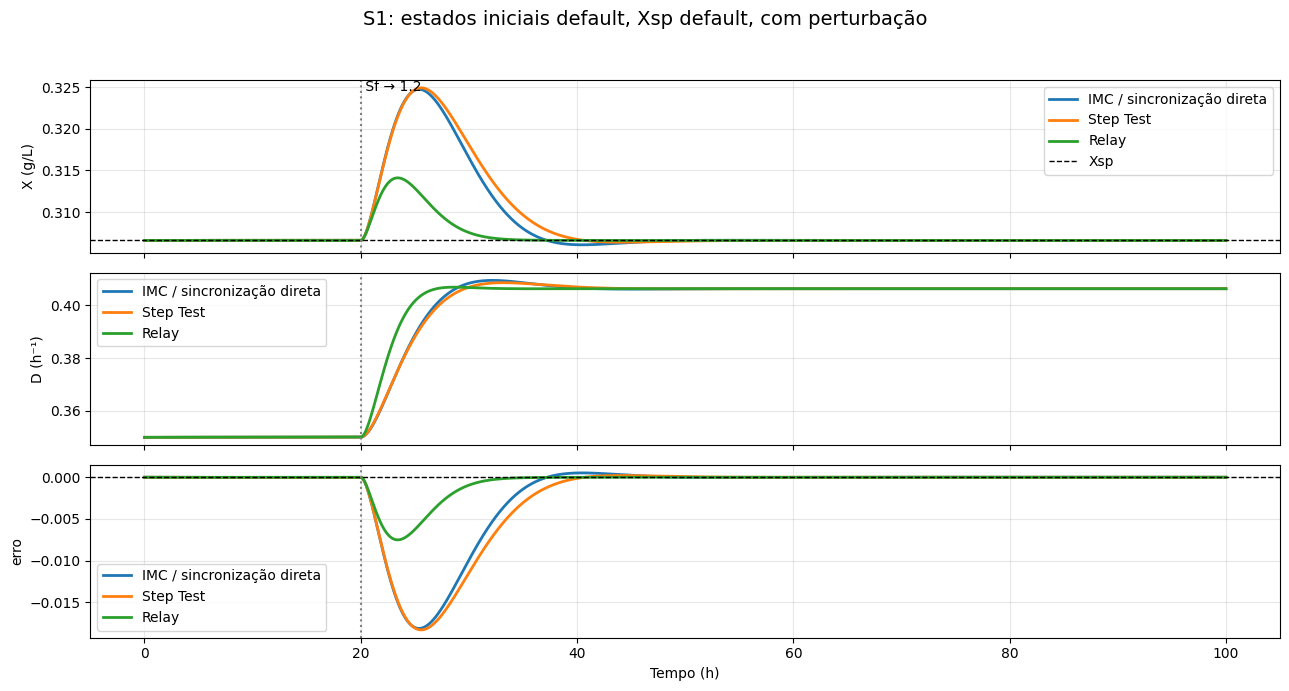

,Cenário,Controlador,Kc,Ti,IAE,ISE
0,"S1: estados iniciais default, Xsp default, com...",IMC / sincronização direta,-1.087364,2.900,0.157028,0.002044
1,"S1: estados iniciais default, Xsp default, com...",Step Test,-1.170991,3.520,0.172259,0.002262
2,"S1: estados iniciais default, Xsp default, com...",Relay,-2.841000,2.231,0.044196,0.000234


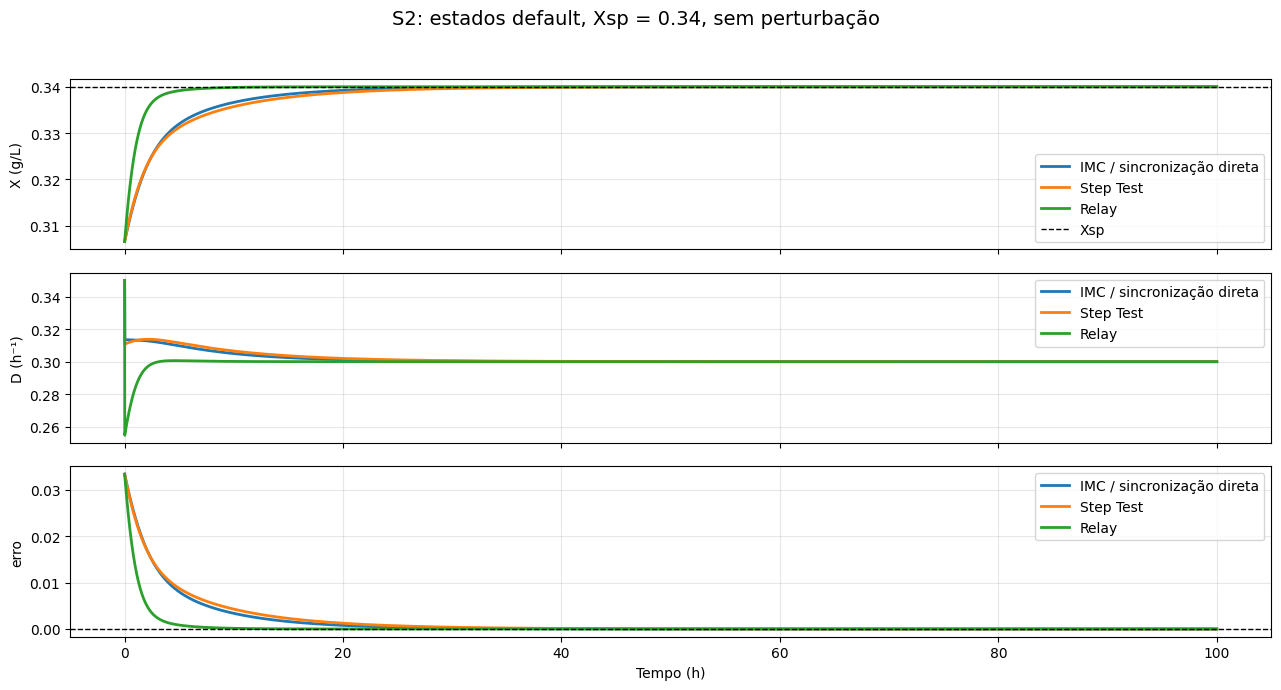

,Cenário,Controlador,Kc,Ti,IAE,ISE
0,"S2: estados default, Xsp = 0.34, sem perturbação",IMC / sincronização direta,-1.087364,2.900,0.133183,0.001849
1,"S2: estados default, Xsp = 0.34, sem perturbação",Step Test,-1.170991,3.520,0.150132,0.001935
2,"S2: estados default, Xsp = 0.34, sem perturbação",Relay,-2.841000,2.231,0.039097,0.000608


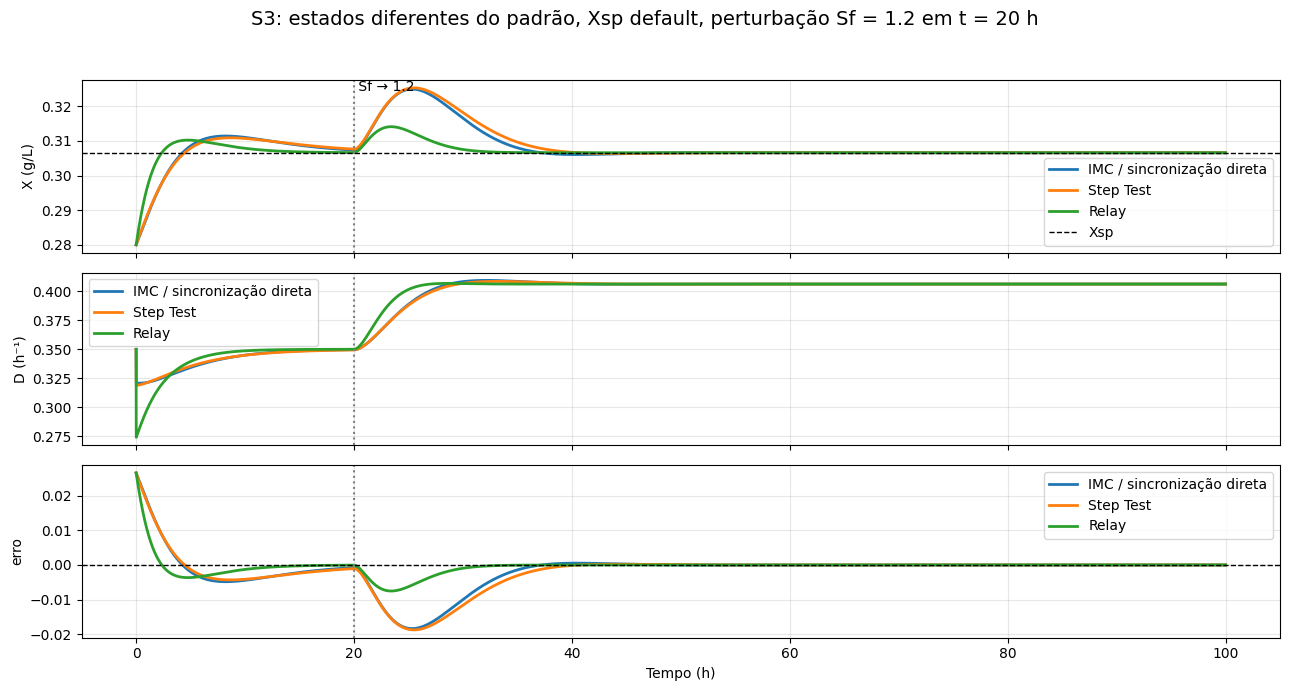

,Cenário,Controlador,Kc,Ti,IAE,ISE
0,"S3: estados diferentes do padrão, Xsp default,...",IMC / sincronização direta,-1.087364,2.900,0.253389,0.003077
1,"S3: estados diferentes do padrão, Xsp default,...",Step Test,-1.170991,3.520,0.269141,0.003321
2,"S3: estados diferentes do padrão, Xsp default,...",Relay,-2.841000,2.231,0.091122,0.000663


In [7]:
resultados_sincronizacao = comparar_metodos_sincronizacao()